##  Importing basic but necessary libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import warnings
warnings.filterwarnings("ignore")

##  EDA

## - Loading dataset and understanding the data

In [2]:
stellar = pd.read_csv("star_classification.csv")

# Creating a copy of dataframe as a backup
stellar_copy = stellar

In [3]:
# Checking the data
stellar.head()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


In [4]:
# Checking the datatypes in our dataset
stellar.info()
# No null values found

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  object 
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7),

In [5]:
stellar.shape

(100000, 18)

In [6]:
# Checking the count of the three classes of Stellar objects we have in our data.
stellar["class"].value_counts()

GALAXY    59445
STAR      21594
QSO       18961
Name: class, dtype: int64

In [7]:
# We will drop object_id & rerun_ID due to the following reasons: \
# Obj_ID is not required because the indexing pattern of the data will \
# differentiate each point from the other.
# rerun_ID has the same value for all data points.
stellar.drop(['obj_ID','rerun_ID'], axis = 1, inplace = True)

In [8]:
stellar.head()

,alpha,delta,u,g,r,i,z,run_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


In [9]:
stellar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   alpha        100000 non-null  float64
 1   delta        100000 non-null  float64
 2   u            100000 non-null  float64
 3   g            100000 non-null  float64
 4   r            100000 non-null  float64
 5   i            100000 non-null  float64
 6   z            100000 non-null  float64
 7   run_ID       100000 non-null  int64  
 8   cam_col      100000 non-null  int64  
 9   field_ID     100000 non-null  int64  
 10  spec_obj_ID  100000 non-null  float64
 11  class        100000 non-null  object 
 12  redshift     100000 non-null  float64
 13  plate        100000 non-null  int64  
 14  MJD          100000 non-null  int64  
 15  fiber_ID     100000 non-null  int64  
dtypes: float64(9), int64(6), object(1)
memory usage: 12.2+ MB


In [10]:
stellar.shape

(100000, 16)

In [11]:
stellar["class"].value_counts()

GALAXY    59445
STAR      21594
QSO       18961
Name: class, dtype: int64

In [12]:
numeric_cols = stellar.select_dtypes(include=['number']).columns

In [13]:
numeric_cols

Index(['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'run_ID', 'cam_col',
       'field_ID', 'spec_obj_ID', 'redshift', 'plate', 'MJD', 'fiber_ID'],
      dtype='object')

In [14]:
categ_cols = stellar.select_dtypes(include=['object']).columns

In [15]:
categ_cols

Index(['class'], dtype='object')

### - Visualising

<AxesSubplot:xlabel='class', ylabel='count'>

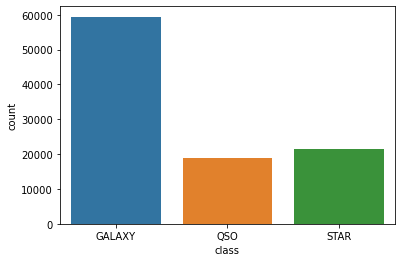

In [16]:
sb.countplot(stellar["class"])

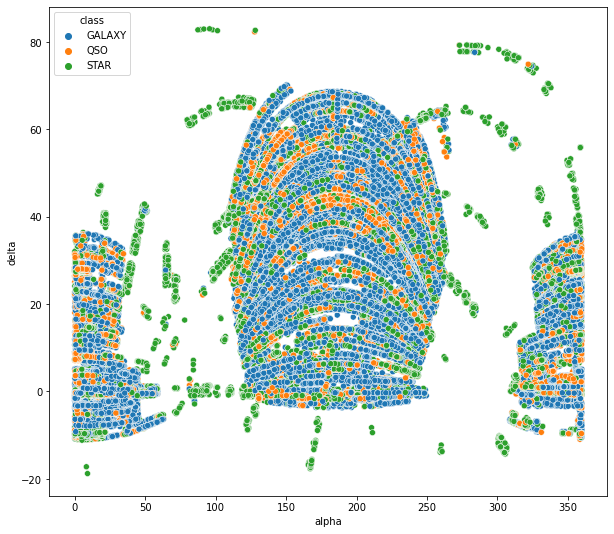

In [17]:
plt.figure(figsize=(10,9))
sb.scatterplot(x="alpha", y="delta", data = stellar, hue="class")
plt.show()

The output of this graph does not provide a lot of insights, hence we will explore other graph types to gain insights

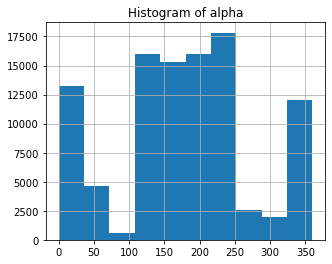

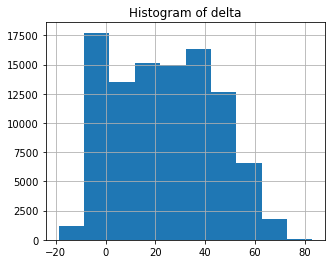

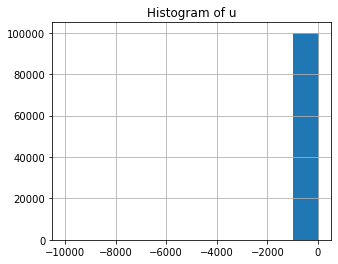

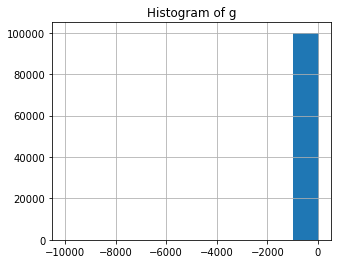

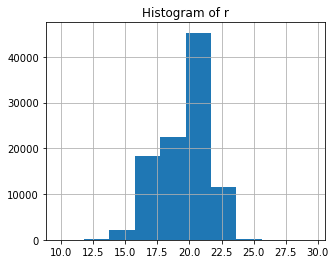

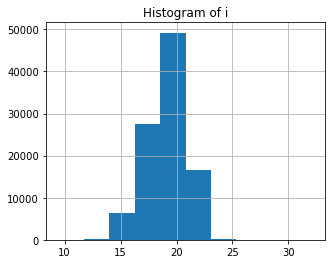

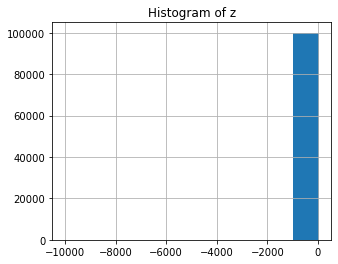

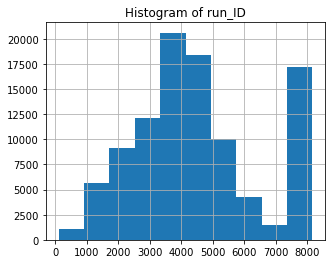

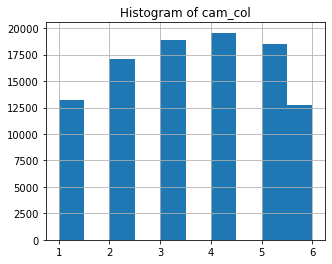

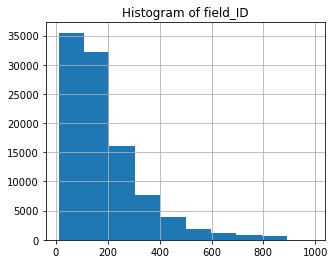

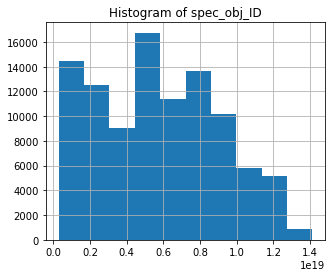

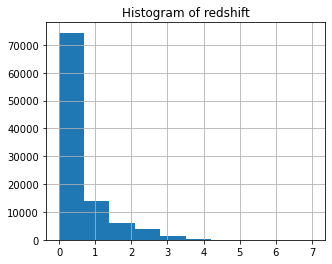

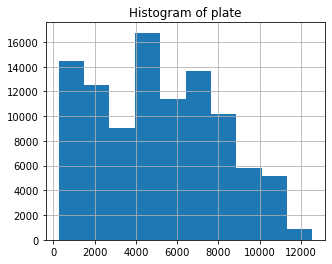

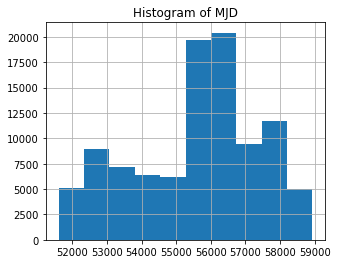

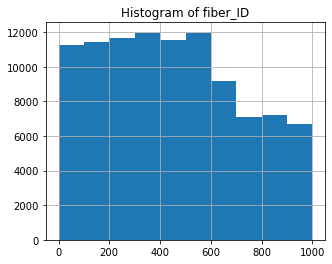

In [18]:
for column in numeric_cols:
    plt.figure(figsize=(5,4))
    stellar[column].hist()
    plt.title(f"Histogram of {column}")

We will check KDE plots as well to understand the probability distribution of variables

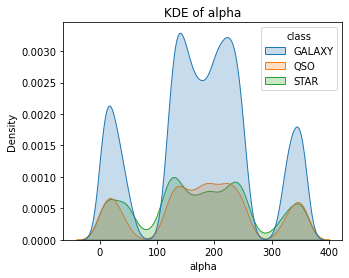

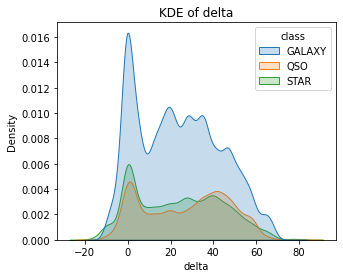

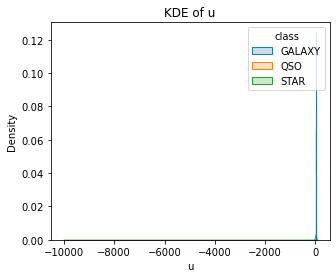

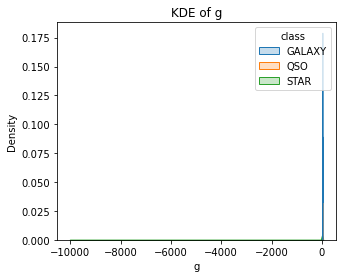

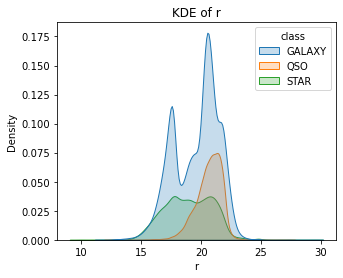

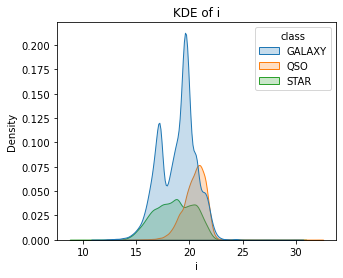

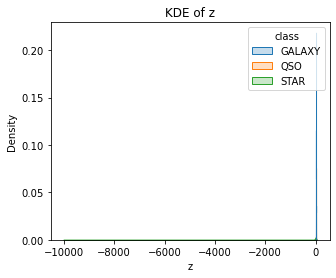

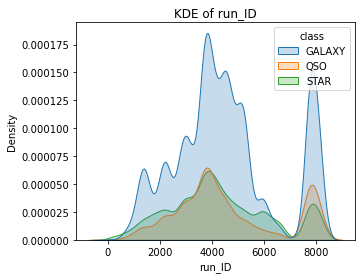

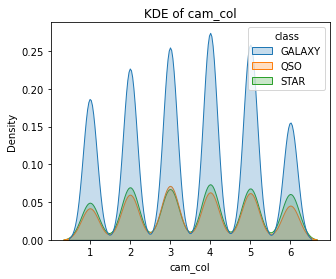

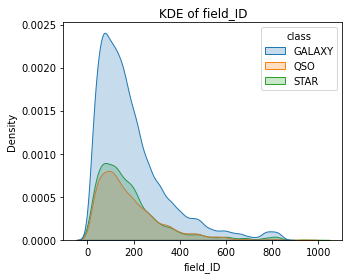

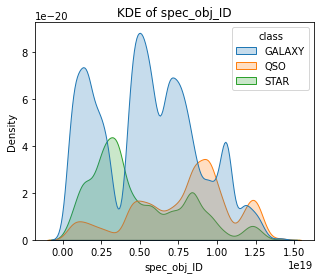

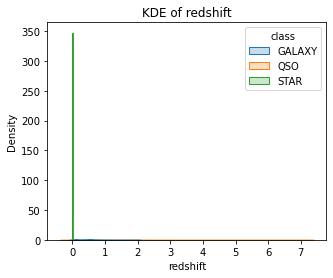

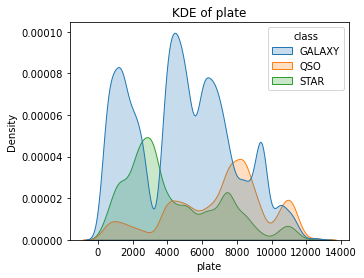

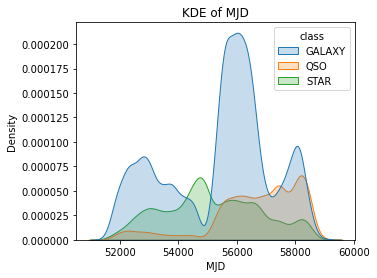

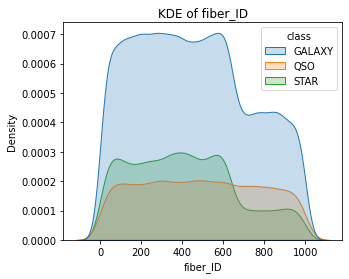

In [19]:
for column in numeric_cols:
    plt.figure(figsize=(5,4))
    sb.kdeplot(data=stellar, x = column, hue = "class", fill = True )
    plt.title(f"KDE of {column}")

We will also use BoxPlots get details about Outliers

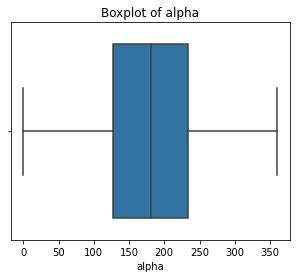

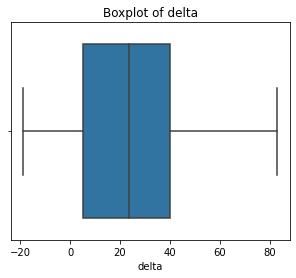

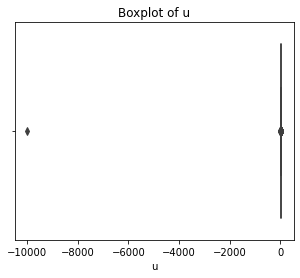

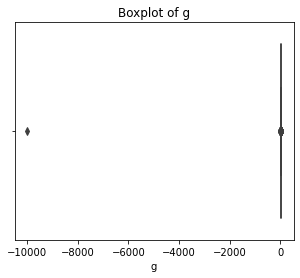

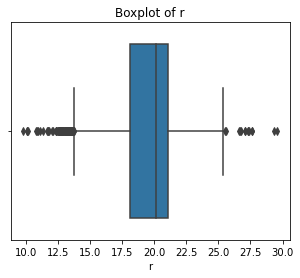

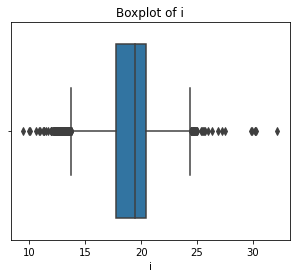

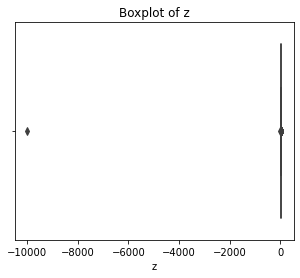

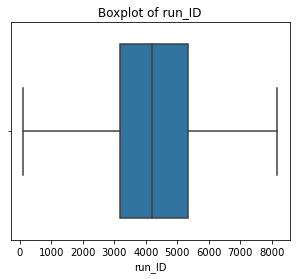

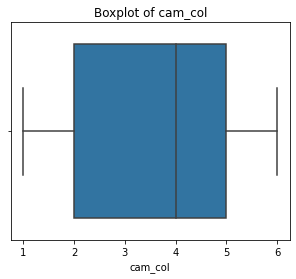

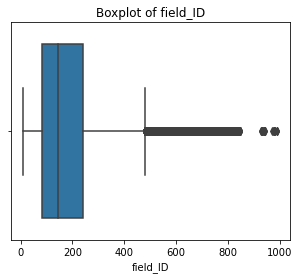

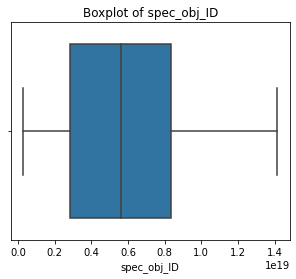

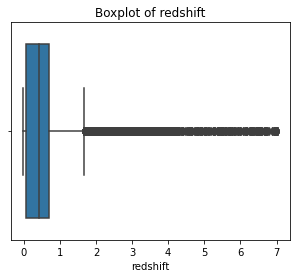

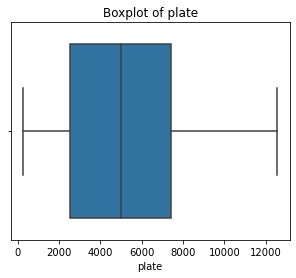

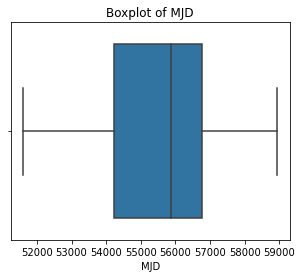

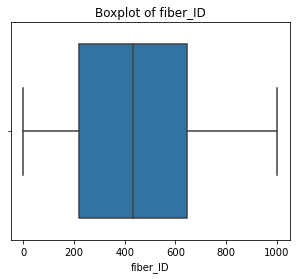

In [20]:
for column in numeric_cols:
    plt.figure(figsize=(5,4))
    sb.boxplot(x = stellar[column])
    plt.title(f"Boxplot of {column}")

We will also take a look at features related to the wavelength and position of the celestial bodies

In [21]:
imp_features = ["alpha","delta","r","i","redshift","class"]

Let us visualize these features

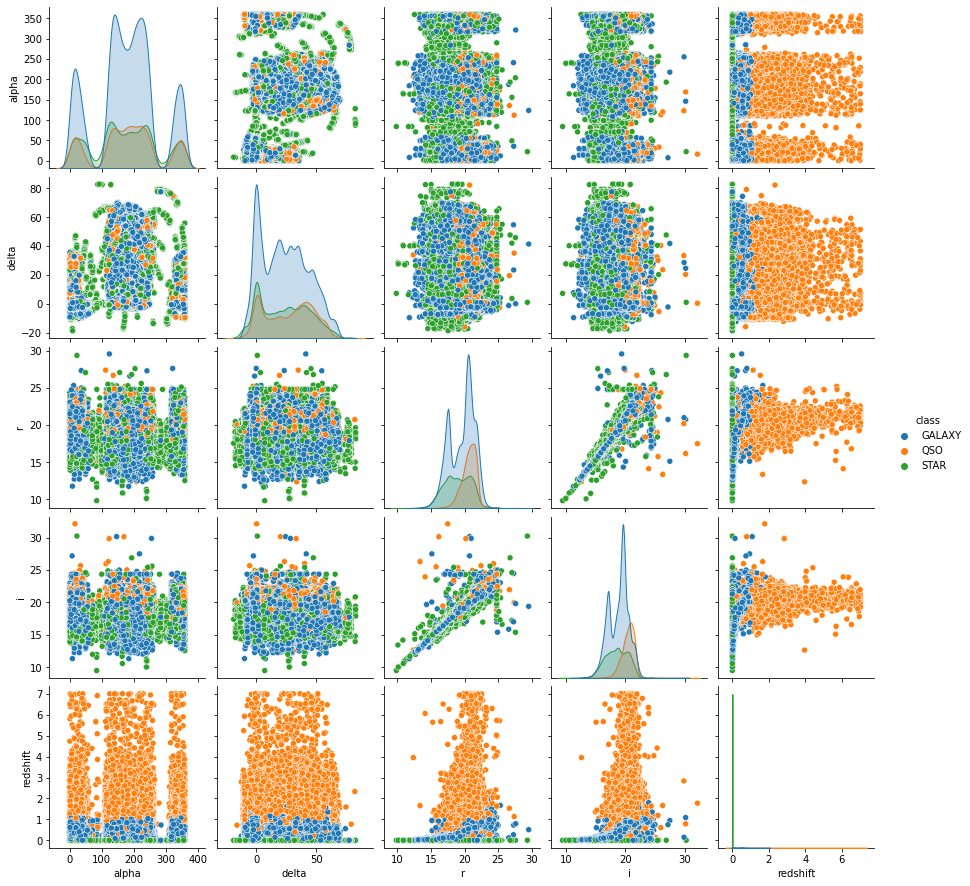

In [22]:
sb.pairplot(stellar[imp_features], hue="class")

## Converting the categorical target variables into numeric data

###  Using Label Encoder to achieve it

In [23]:
from sklearn.preprocessing import LabelEncoder

In [24]:
le = LabelEncoder()
stellar["class"] = le.fit_transform(stellar["class"])

In [25]:
stellar.head(10)
# The classes have now been converted as \
# Galaxy = 0; Quasars = 1; Stars = 2.


,alpha,delta,u,g,r,i,z,run_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,2,79,6.543777e+18,0,0.634794,5812,56354,171
1,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,5,119,1.176014e+19,0,0.779136,10445,58158,427
2,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,2,120,5.152200e+18,0,0.644195,4576,55592,299
3,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,3,214,1.030107e+19,0,0.932346,9149,58039,775
4,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,3,137,6.891865e+18,0,0.116123,6121,56187,842
5,340.995121,20.589476,23.48827,23.33776,21.32195,20.25615,19.54544,8102,3,110,5.658977e+18,1,1.424659,5026,55855,741
6,23.234926,11.418188,21.46973,21.17624,20.92829,20.60826,20.42573,7773,2,462,1.246262e+19,1,0.586455,11069,58456,113
7,5.433176,12.065186,22.24979,22.02172,20.34126,19.48794,18.84999,7773,2,346,6.961443e+18,0,0.477009,6183,56210,15
8,200.290475,47.199402,24.40286,22.35669,20.61032,19.46490,18.95852,3716,5,108,7.459285e+18,0,0.660012,6625,56386,719
9,39.149691,28.102842,21.74669,20.03493,19.17553,18.81823,18.65422,5934,4,122,2.751763e+18,2,-0.000008,2444,54082,232


In [26]:
stellar.info()
# Here we can confirm all features are numerical now

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   alpha        100000 non-null  float64
 1   delta        100000 non-null  float64
 2   u            100000 non-null  float64
 3   g            100000 non-null  float64
 4   r            100000 non-null  float64
 5   i            100000 non-null  float64
 6   z            100000 non-null  float64
 7   run_ID       100000 non-null  int64  
 8   cam_col      100000 non-null  int64  
 9   field_ID     100000 non-null  int64  
 10  spec_obj_ID  100000 non-null  float64
 11  class        100000 non-null  int32  
 12  redshift     100000 non-null  float64
 13  plate        100000 non-null  int64  
 14  MJD          100000 non-null  int64  
 15  fiber_ID     100000 non-null  int64  
dtypes: float64(9), int32(1), int64(6)
memory usage: 11.8 MB


## Checking for and handling outliers

In [27]:
from sklearn.neighbors import LocalOutlierFactor

# Creating an object of LocalOutlierFactor
lof = LocalOutlierFactor()

In [28]:
y_pred = lof.fit_predict(stellar)
# The line of code above will fit the model to our dataset and predict which \
# datapoints are outliers (1 is inlier and -1 is outlier)

In [29]:
y_pred
# (1 is inlier and -1 is outlier)

array([ 1,  1, -1, ...,  1, -1,  1])

In [30]:
outlier_scores = lof.negative_outlier_factor_
# The above mentioned line of code returns the negative outlier factor \
# (LOF score) for each data point. We will consider the datapoints with \
# scores closer to 1 to be inliers.


In [31]:
outlier_scores

array([-1.06517956, -0.96527697, -1.53654319, ..., -0.99867755,
       -1.75013308, -1.02859662])

In [32]:
outlier_score_df = pd.DataFrame()
outlier_score_df["Scores"] = outlier_scores
# Stored the scores in a new dataframe.

In [33]:
outlier_score_df

,Scores
0,-1.065180
1,-0.965277
2,-1.536543
3,-1.463513
4,-1.114226
...,...
99995,-0.967860
99996,-0.998818
99997,-0.998678
99998,-1.750133


In [34]:
# We will now apply a threshold of -1.5 to the outlier_score_df \
# so that we can classify the datapoints as an inlier or outlier

threshold = -1.5
filters = outlier_score_df["Scores"] < threshold

In [35]:
filters
# This is the list stating if the datapoints are inliers or outliers \
# based on our applied threshold.
# The ones with value 'True' are outliers.

0        False
1        False
2         True
3        False
4        False
         ...  
99995    False
99996    False
99997    False
99998     True
99999    False
Name: Scores, Length: 100000, dtype: bool

In [36]:
# We can view only the ones which are outliers.
filters[filters == True]

2        True
5        True
20       True
23       True
54       True
         ... 
99970    True
99972    True
99974    True
99985    True
99998    True
Name: Scores, Length: 15258, dtype: bool

In [37]:
# If we compare these indices with our 'y_pred' which used fit_predict() \
# function we can confirm that the results are accurate.
print("filters[97]:", filters[97],", y_pred[97]:",y_pred[97])
print("filters[119]:", filters[119],", y_pred[119]:", y_pred[119])

filters[97]: False , y_pred[97]: 1
filters[119]: True , y_pred[119]: -1


In [38]:
# Now we will store these indices in a list so that we can manipulate them
# through indices itself.

outlier_indices = outlier_score_df[filters].index.tolist()

# outlier_score[filtre2] filters the outlier_score DataFrame to select rows \
# where the LOF score is less than -1.5, i.e., the outliers.
# .index.tolist() extracts the indices of the outliers and stores them in \
# the list outlier_indices.

outlier_indices

[2,
 5,
 20,
 23,
 54,
 56,
 61,
 65,
 67,
 73,
 88,
 90,
 92,
 117,
 119,
 125,
 126,
 138,
 139,
 141,
 148,
 150,
 151,
 153,
 156,
 158,
 162,
 169,
 176,
 181,
 183,
 191,
 192,
 196,
 199,
 202,
 204,
 206,
 207,
 217,
 219,
 220,
 225,
 230,
 238,
 244,
 259,
 261,
 262,
 267,
 272,
 289,
 291,
 300,
 308,
 310,
 311,
 313,
 319,
 321,
 325,
 326,
 332,
 333,
 336,
 348,
 349,
 352,
 353,
 356,
 359,
 367,
 370,
 373,
 389,
 395,
 396,
 400,
 405,
 414,
 415,
 417,
 427,
 428,
 436,
 442,
 455,
 468,
 473,
 482,
 485,
 495,
 502,
 506,
 511,
 519,
 527,
 528,
 530,
 532,
 537,
 551,
 561,
 582,
 594,
 595,
 596,
 602,
 611,
 631,
 640,
 644,
 650,
 651,
 653,
 665,
 666,
 669,
 671,
 676,
 681,
 691,
 700,
 701,
 716,
 726,
 728,
 730,
 731,
 734,
 754,
 756,
 772,
 773,
 775,
 779,
 782,
 787,
 800,
 801,
 802,
 809,
 811,
 813,
 818,
 819,
 826,
 829,
 831,
 832,
 833,
 857,
 860,
 861,
 866,
 868,
 875,
 877,
 882,
 886,
 888,
 889,
 906,
 916,
 925,
 929,
 936,
 938,
 945,
 

In [39]:
# We will check the number of outlier indices we have.

len(outlier_indices)

15258

In [40]:
# We will now drop thes values on these indices from our 'stellar' dataset

stellar.drop(outlier_indices, inplace = True)

In [41]:
stellar.reset_index(drop = True)

,alpha,delta,u,g,r,i,z,run_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,2,79,6.543777e+18,0,0.634794,5812,56354,171
1,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,5,119,1.176014e+19,0,0.779136,10445,58158,427
2,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,3,214,1.030107e+19,0,0.932346,9149,58039,775
3,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,3,137,6.891865e+18,0,0.116123,6121,56187,842
4,23.234926,11.418188,21.46973,21.17624,20.92829,20.60826,20.42573,7773,2,462,1.246262e+19,1,0.586455,11069,58456,113
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84737,317.246996,-0.682254,20.96526,19.81625,19.34186,19.14711,19.05790,4187,2,64,1.154061e+18,0,0.175206,1025,53239,51
84738,39.620709,-2.594074,22.16759,22.97586,21.90404,21.30548,20.73569,7778,2,581,1.055431e+19,0,0.000000,9374,57749,438
84739,29.493819,19.798874,22.69118,22.38628,20.45003,19.75759,19.41526,7917,1,289,8.586351e+18,0,0.404895,7626,56934,866
84740,224.587407,15.700707,21.16916,19.26997,18.20428,17.69034,17.35221,5314,4,308,3.112008e+18,0,0.143366,2764,54535,74


In [42]:
stellar.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 84742 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   alpha        84742 non-null  float64
 1   delta        84742 non-null  float64
 2   u            84742 non-null  float64
 3   g            84742 non-null  float64
 4   r            84742 non-null  float64
 5   i            84742 non-null  float64
 6   z            84742 non-null  float64
 7   run_ID       84742 non-null  int64  
 8   cam_col      84742 non-null  int64  
 9   field_ID     84742 non-null  int64  
 10  spec_obj_ID  84742 non-null  float64
 11  class        84742 non-null  int32  
 12  redshift     84742 non-null  float64
 13  plate        84742 non-null  int64  
 14  MJD          84742 non-null  int64  
 15  fiber_ID     84742 non-null  int64  
dtypes: float64(9), int32(1), int64(6)
memory usage: 10.7 MB


In [43]:
stellar.describe()

,alpha,delta,u,g,r,i,z,run_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
count,84742.000000,84742.000000,84742.000000,84742.000000,84742.000000,84742.000000,84742.000000,84742.000000,84742.000000,84742.000000,8.474200e+04,84742.000000,84742.000000,84742.000000,84742.000000,84742.000000
mean,178.098435,24.017316,22.075063,20.624504,19.639477,19.080563,18.765686,4481.198992,3.539780,185.665361,5.760718e+18,0.612848,0.577136,5116.435310,55574.438130,450.013335
std,96.525589,19.611592,2.242909,2.025213,1.847432,1.755214,1.765564,1958.886978,1.584259,149.052438,3.321669e+18,0.812064,0.728735,2950.219191,1813.342713,270.248465
min,0.005528,-17.636198,10.996230,12.679020,11.746640,11.299560,10.897380,109.000000,1.000000,11.000000,2.995191e+17,0.000000,-0.009971,266.000000,51608.000000,1.000000
25%,128.134729,4.698355,20.350338,18.959333,18.124682,17.722680,17.445142,3187.000000,2.000000,82.000000,2.801648e+18,0.000000,0.060015,2488.250000,54212.000000,224.000000
50%,181.296294,23.731387,22.165550,21.086290,20.113800,19.396945,18.999250,4188.000000,4.000000,146.000000,5.604922e+18,0.000000,0.424282,4978.000000,55866.000000,435.000000
75%,233.942593,39.809697,23.672702,22.116512,21.029492,20.384238,19.922350,5323.000000,5.000000,239.000000,8.322746e+18,1.000000,0.704190,7392.000000,56772.000000,643.000000
max,359.999810,79.343076,32.781390,31.602240,29.571860,32.141470,29.383740,8162.000000,6.000000,989.000000,1.412685e+19,2.000000,7.011245,12547.000000,58932.000000,1000.000000


In [44]:
stellar.shape

(84742, 16)

## Feature Selection

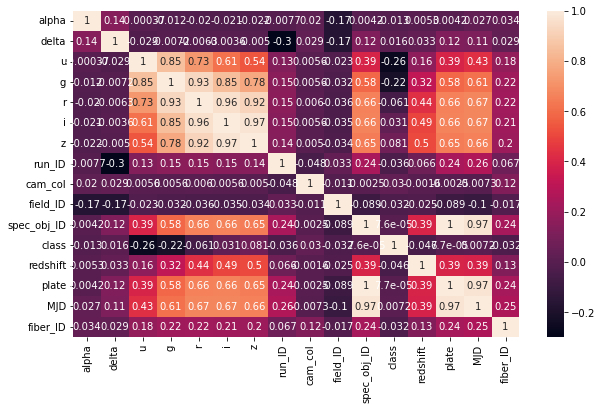

In [45]:
f,ax = plt.subplots(figsize=(10,6))
sb.heatmap(stellar.corr(), annot = True)
plt.show()

In [46]:
corr = stellar.corr()
corr

,alpha,delta,u,g,r,i,z,run_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
alpha,1.000000,0.138306,-0.000374,-0.011991,-0.019814,-0.020522,-0.022371,-0.007678,0.019833,-0.169498,0.004186,-0.013217,0.005290,0.004185,0.026927,0.034386
delta,0.138306,1.000000,-0.028893,-0.007238,-0.006328,-0.003579,-0.005036,-0.298550,0.029281,-0.168236,0.119308,0.015818,0.033144,0.119308,0.113703,0.028953
u,-0.000374,-0.028893,1.000000,0.851753,0.725018,0.614297,0.541829,0.131695,0.005649,-0.023391,0.394011,-0.263352,0.164296,0.394009,0.434768,0.180434
g,-0.011991,-0.007238,0.851753,1.000000,0.932444,0.846497,0.775087,0.151539,0.005598,-0.032490,0.584540,-0.216076,0.319077,0.584538,0.611316,0.218435
r,-0.019814,-0.006328,0.725018,0.932444,1.000000,0.962662,0.918968,0.154271,0.005981,-0.035645,0.657687,-0.061366,0.435057,0.657685,0.673406,0.221742
i,-0.020522,-0.003579,0.614297,0.846497,0.962662,1.000000,0.971291,0.147700,0.005564,-0.034789,0.664596,0.030622,0.494444,0.664594,0.674896,0.213938
z,-0.022371,-0.005036,0.541829,0.775087,0.918968,0.971291,1.000000,0.140514,0.004988,-0.033912,0.647838,0.081287,0.503364,0.647837,0.656424,0.203701
run_ID,-0.007678,-0.298550,0.131695,0.151539,0.154271,0.147700,0.140514,1.000000,-0.048233,0.032548,0.240280,-0.035703,0.066430,0.240280,0.263391,0.067189
cam_col,0.019833,0.029281,0.005649,0.005598,0.005981,0.005564,0.004988,-0.048233,1.000000,-0.010866,-0.002505,0.030243,-0.001560,-0.002508,-0.007286,0.123513
field_ID,-0.169498,-0.168236,-0.023391,-0.032490,-0.035645,-0.034789,-0.033912,0.032548,-0.010866,1.000000,-0.089238,-0.032320,-0.025334,-0.089238,-0.104030,-0.017447


In [47]:
corr["class"].sort_values()

u             -0.263352
g             -0.216076
r             -0.061366
redshift      -0.045657
run_ID        -0.035703
field_ID      -0.032320
fiber_ID      -0.031726
alpha         -0.013217
spec_obj_ID    0.000076
plate          0.000077
MJD            0.007209
delta          0.015818
cam_col        0.030243
i              0.030622
z              0.081287
class          1.000000
Name: class, dtype: float64

In [48]:
stellar.drop(["field_ID","fiber_ID", "cam_col","run_ID", "spec_obj_ID","plate","MJD"], axis = 1, inplace = True)

We dropped the above features as they are not relevant for a celestial body's classification

In [49]:
stellar.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 84742 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   alpha     84742 non-null  float64
 1   delta     84742 non-null  float64
 2   u         84742 non-null  float64
 3   g         84742 non-null  float64
 4   r         84742 non-null  float64
 5   i         84742 non-null  float64
 6   z         84742 non-null  float64
 7   class     84742 non-null  int32  
 8   redshift  84742 non-null  float64
dtypes: float64(8), int32(1)
memory usage: 6.1 MB


In [50]:
stellar.shape

(84742, 9)

## Fixing imbalance in data

In [51]:
from imblearn.over_sampling import SMOTE
from collections import Counter

In [52]:
x = stellar.drop("class", axis = 1)
y = stellar["class"].values

In [53]:
x

,alpha,delta,u,g,r,i,z,redshift
0,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,0.634794
1,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,0.779136
3,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,0.932346
4,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,0.116123
6,23.234926,11.418188,21.46973,21.17624,20.92829,20.60826,20.42573,0.586455
...,...,...,...,...,...,...,...,...
99994,317.246996,-0.682254,20.96526,19.81625,19.34186,19.14711,19.05790,0.175206
99995,39.620709,-2.594074,22.16759,22.97586,21.90404,21.30548,20.73569,0.000000
99996,29.493819,19.798874,22.69118,22.38628,20.45003,19.75759,19.41526,0.404895
99997,224.587407,15.700707,21.16916,19.26997,18.20428,17.69034,17.35221,0.143366


In [54]:
y

array([0, 0, 0, ..., 0, 0, 0])

In [55]:
smote = SMOTE(random_state = 42)
print("Datapoints before SMOTE: ", Counter(y))

Datapoints before SMOTE:  Counter({0: 50696, 2: 17888, 1: 16158})


In [56]:
# Here we will use the fit_resample method so that synthetic points are generated.
x,y = smote.fit_resample(x,y)

In [57]:
print("Resampled datapoints after SMOTE: ", Counter(y))

Resampled datapoints after SMOTE:  Counter({0: 50696, 1: 50696, 2: 50696})


<AxesSubplot:ylabel='count'>

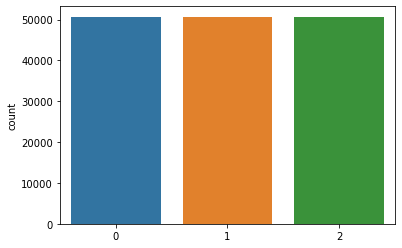

In [58]:
# Verifying with visualisation method
sb.countplot(y)

## Data Scaling

In [59]:
from sklearn.preprocessing import StandardScaler

In [60]:
scaler = StandardScaler()

In [61]:
x = scaler.fit_transform(x)

In [62]:
# Visualising Standardised 'x' as a DataFrame
pd.DataFrame(x)

,0,1,2,3,4,5,6,7
0,-0.433085,0.403515,1.012783,0.942918,0.373895,-0.070739,-0.135396,-0.082005
1,-0.339779,0.341868,1.438805,1.235175,1.597000,1.076001,1.461875,0.083337
2,1.640462,-1.258201,0.187064,1.731221,1.053543,0.695978,0.123056,0.258836
3,1.707263,-0.167814,-1.092583,-1.522412,-1.803428,-1.896816,-1.975348,-0.676134
4,-1.581456,-0.661098,-0.129141,0.365807,0.671807,0.755377,0.788810,-0.137376
...,...,...,...,...,...,...,...,...
152083,0.300439,-0.513395,0.119432,0.275697,0.722068,1.003436,1.032025,-0.809261
152084,0.715168,0.742329,-0.050388,0.226507,0.512497,0.692844,0.871100,-0.809534
152085,1.744881,-1.250933,0.676461,0.564501,0.426707,0.024675,-0.212107,-0.809110
152086,-0.293311,-0.398391,-0.801127,-0.162162,-0.270875,-0.382671,-0.473987,-0.809032


## Importing the model libraries

In [63]:
from sklearn.ensemble import RandomForestClassifier
from sklearn import svm
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

In [64]:
from yellowbrick.classifier import ConfusionMatrix
from yellowbrick.classifier import ROCAUC
from yellowbrick.classifier import ClassPredictionError
# These values will help us in visualising the mentioned metrics

### Train-Test Split

In [65]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [66]:
# Checking shapes
print("x_train:", x_train.shape, "\nx_test:", x_test.shape, "\ny_train:", y_train.shape, "\ny_test:", y_test.shape)

x_train: (121670, 8) 
x_test: (30418, 8) 
y_train: (121670,) 
y_test: (30418,)


## Using classifiers

### SVM

In [67]:
svm_clf = svm.SVC(kernel = 'rbf', C = 1, random_state = 0)

# We used the 'rbf' kernel as it is good for problems where the relationship between \
#  the features and the target is complex and non-linear. It which maps input features into a higher-dimensional space \
#  where they become linearly separable.

# The 'C' parameter dictates tolerance of misclassification, where smaller values will allow SVM for few misclassifications, \
#  whereas larger values will reduce misclassification but will also overfit.

In [68]:
svm_clf.fit(x_train, y_train)

SVC(C=1, random_state=0)

In [69]:
predicted = svm_clf.predict(x_test)

In [70]:
predicted

array([1, 0, 2, ..., 0, 1, 0])

In [71]:
score = svm_clf.score(x_test, y_test)

In [72]:
svm_score = np.mean(score)

In [73]:
print("Accuracy: % .3f" % svm_score)

Accuracy:  0.968


### Confusion matrix for SVM

In [74]:
# We have to  will create a list of our classes to enter as a parameter in the confusion matrix
classes = ['GALAXY','QSO','STAR']

In [75]:
svm_conf_mat = ConfusionMatrix(svm_clf, classes = classes, cmap="GnBu")

0.9680123611019791

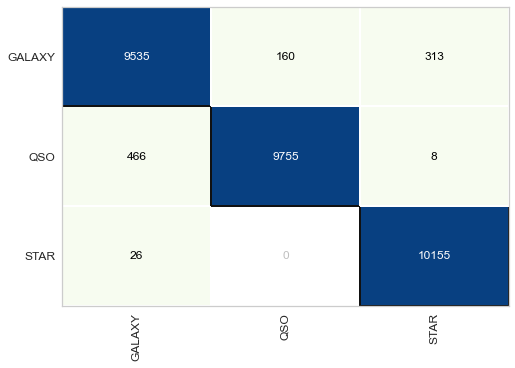

In [76]:

svm_conf_mat.fit(x_train,y_train)
svm_conf_mat.score(x_test, y_test)


In [77]:
print(classification_report(y_test, predicted))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95     10008
           1       0.98      0.95      0.97     10229
           2       0.97      1.00      0.98     10181

    accuracy                           0.97     30418
   macro avg       0.97      0.97      0.97     30418
weighted avg       0.97      0.97      0.97     30418



### ROC Curve

In [78]:
visualiser = ROCAUC(svm_clf, classes=classes)

0.9846478052163453

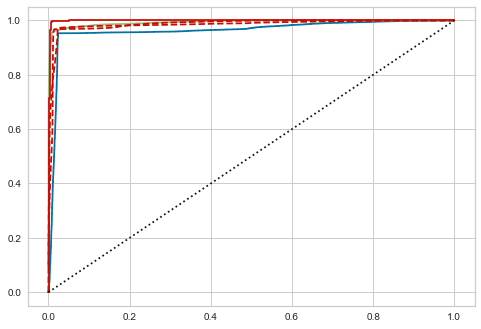

In [79]:
visualiser.fit(x_train,y_train)
visualiser.score(x_test,y_test)

### Class Prediction Error

In [80]:
# Here we will check how our classifier is preforming

visualiser2 = ClassPredictionError(svm_clf, classes=classes)

0.9680123611019791

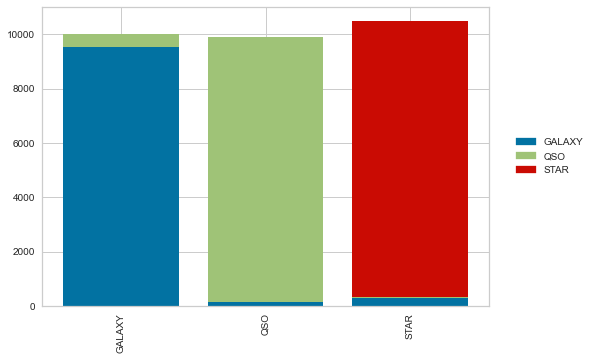

In [81]:
visualiser2.fit(x_train, y_train)
visualiser2.score(x_test, y_test)

## Using RandomForestClassifier

In [82]:
r_forest = RandomForestClassifier()

In [83]:
r_forest.fit(x_train, y_train)

RandomForestClassifier()

In [84]:
predicted = r_forest.predict(x_test)

In [85]:
score2 = r_forest.score(x_test, y_test)
score2

0.9830692353211914

### Confusion Matrix for Random Forest Classifier

In [86]:
r_forest_conf_matrix = ConfusionMatrix(r_forest, classes = classes, cmap = "GnBu")

0.9830692353211914

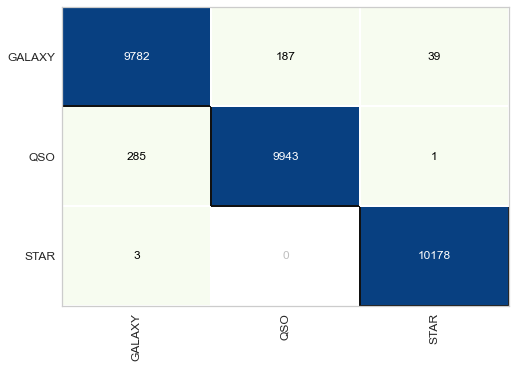

In [87]:
r_forest_conf_matrix.fit(x_train, y_train)
r_forest_conf_matrix.score(x_test, y_test)

In [88]:
print(classification_report(y_test, predicted))

              precision    recall  f1-score   support

           0       0.97      0.98      0.97     10008
           1       0.98      0.97      0.98     10229
           2       1.00      1.00      1.00     10181

    accuracy                           0.98     30418
   macro avg       0.98      0.98      0.98     30418
weighted avg       0.98      0.98      0.98     30418



### ROC Curve

In [89]:
visualizer3 = ROCAUC(r_forest, classes=classes)

0.9982912601778985

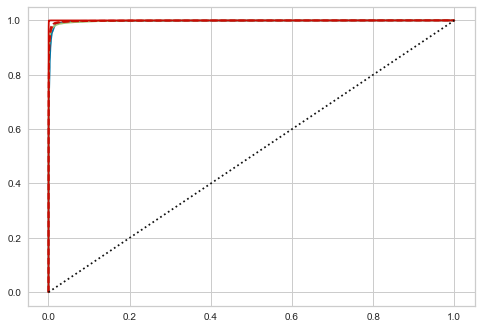

In [90]:
visualizer3.fit(x_train, y_train)
visualizer3.score(x_test, y_test)

### Class prediction error

In [91]:
visualiser4 = ClassPredictionError(r_forest, classes = classes)

0.9830692353211914

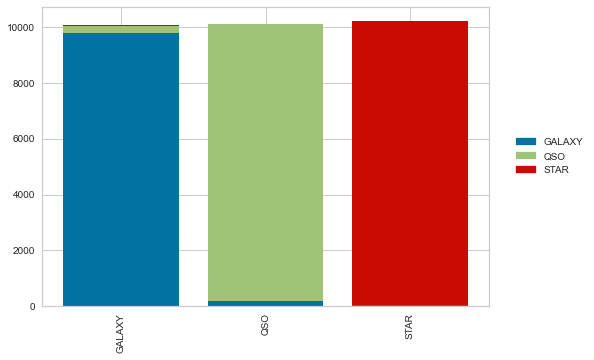

In [92]:
visualiser4.fit(x_train, y_train)
visualiser4.score(x_test, y_test)

## Conclusion

### We can see that the RandomForestClassifier performs best for this problem statement.